# External Sort I/O Cost Analysis

This notebook analyzes the I/O cost of external sorting as a function of thread count.

**Parameters:**
- D = 200 GiB (input size)
- M = 2 GiB (memory budget)
- P = 64 KiB (I/O page size)
- T = varies from 4 to 64 (thread count)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil, log

In [9]:
# Parameters (in bytes)
D = 200 * 1024**3  # 200 GiB
M = 2 * 1024**3    # 2 GiB
P = 64 * 1024      # 64 KiB

# Thread counts to analyze
T_values = np.arange(4, 65, 4)

print(f"D = {D / 1024**3:.1f} GiB")
print(f"M = {M / 1024**3:.1f} GiB")
print(f"P = {P / 1024:.1f} KiB")
print(f"T range: {T_values[0]} to {T_values[-1]}")

D = 200.0 GiB
M = 2.0 GiB
P = 64.0 KiB
T range: 4 to 64


In [10]:
def compute_L_avg(N, F):
    """
    Compute average merge levels for Huffman merge.
    
    Args:
        N: Number of runs
        F: Merge fan-in
    
    Returns:
        L_avg: Average number of merge levels
    """
    if F >= N:
        # Single pass merge
        return 1.0
    
    # Add dummy runs to make N' ≡ 1 (mod F-1)
    d = (1 - N) % (F - 1)
    N_prime = N + d
    
    # Height of F-ary merge tree
    h = ceil(log(N_prime) / log(F))
    
    # Number of leaves at depth h-1
    t = (F**h - N_prime) / (F - 1)
    
    # Average merge levels
    L_avg = h - t / N
    
    return L_avg

In [11]:
def compute_threshold(D, M, P):
    """
    Compute the threshold T* = M√2 / √(DP)
    """
    return M * np.sqrt(2) / np.sqrt(D * P)

T_star = compute_threshold(D, M, P)
print(f"Regime boundary: T* = {T_star:.2f} threads")
print(f"Regime 1 (single-pass feasible): T ≤ {T_star:.2f}")
print(f"Regime 2 (multi-pass required): T > {T_star:.2f}")

Regime boundary: T* = 25.60 threads
Regime 1 (single-pass feasible): T ≤ 25.60
Regime 2 (multi-pass required): T > 25.60


In [12]:
def analyze_io_cost(T, D, M, P, strategy="full_parallelism"):
    """
    Compute total I/O cost for a given thread count.
    
    Args:
        T: Number of threads
        D: Data size
        M: Memory budget
        P: Page size
        strategy: "full_parallelism" (Strategy 4) or "throttle" (Strategy 3)
    
    Returns:
        dict with: total_io, run_gen_io, merge_io, N, F, h, L_avg
    """
    # Run generation
    RS = 2 * M / T
    N = ceil(D / RS)
    run_gen_io = 2 * D
    
    # Determine merge fan-in based on memory constraint
    # During merge: F × T × P ≤ M  =>  F ≤ M / (T × P)
    F_max = int(M / (T * P))
    
    if strategy == "full_parallelism":
        # Use maximum fan-in allowed by memory
        F = max(2, min(F_max, N))  # F must be at least 2
    else:
        # Throttle to achieve single-pass
        T_star = compute_threshold(D, M, P)
        if T <= T_star:
            F = N  # Single pass
        else:
            # Use T* threads for merge
            F_max_throttled = int(M / (T_star * P))
            F = max(2, min(F_max_throttled, N))
    
    # Compute merge I/O
    L_avg = compute_L_avg(N, F)
    merge_io = 2 * D * L_avg
    total_io = run_gen_io + merge_io
    
    # Merge tree height
    h = ceil(log(N) / log(F)) if F < N else 1
    
    return {
        'total_io': total_io,
        'run_gen_io': run_gen_io,
        'merge_io': merge_io,
        'N': N,
        'F': F,
        'h': h,
        'L_avg': L_avg,
        'RS': RS
    }

In [13]:
# Analyze for all thread counts
results_full = []
results_throttle = []

for T in T_values:
    results_full.append(analyze_io_cost(T, D, M, P, strategy="full_parallelism"))
    results_throttle.append(analyze_io_cost(T, D, M, P, strategy="throttle"))

# Extract data for plotting
total_io_full = np.array([r['total_io'] for r in results_full]) / D
total_io_throttle = np.array([r['total_io'] for r in results_throttle]) / D
merge_io_full = np.array([r['merge_io'] for r in results_full]) / D
N_values = np.array([r['N'] for r in results_full])
F_values = np.array([r['F'] for r in results_full])
h_values = np.array([r['h'] for r in results_full])

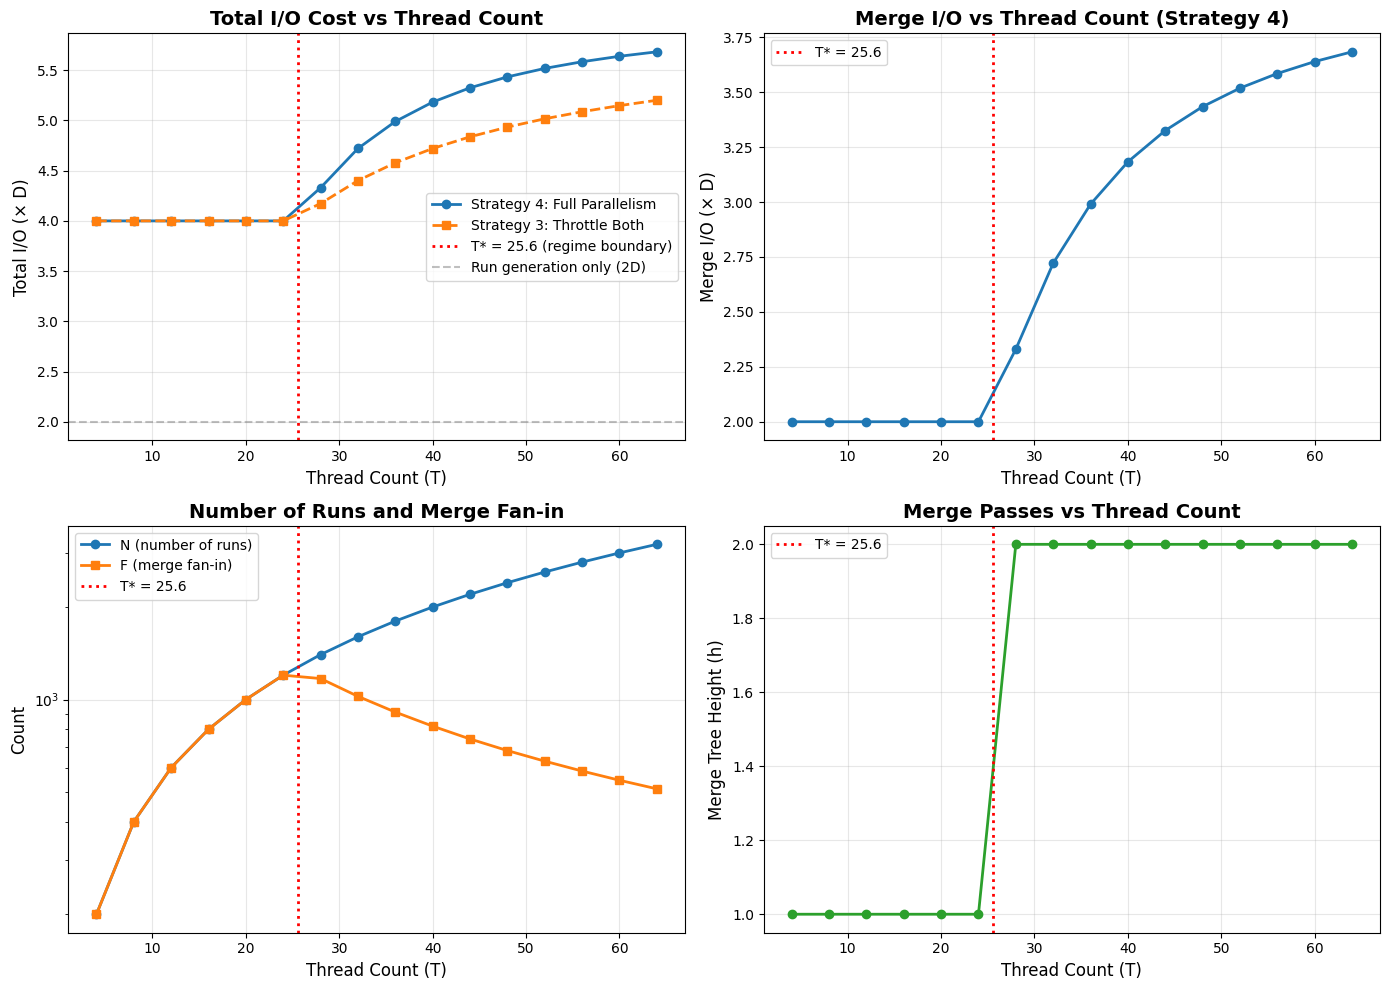


Plot saved to: fig/io_cost_vs_threads.png


In [14]:
# Create comprehensive plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total I/O Cost vs Thread Count
ax1 = axes[0, 0]
ax1.plot(T_values, total_io_full, 'o-', label='Strategy 4: Full Parallelism', linewidth=2, markersize=6)
ax1.plot(T_values, total_io_throttle, 's--', label='Strategy 3: Throttle Both', linewidth=2, markersize=6)
ax1.axvline(T_star, color='red', linestyle=':', linewidth=2, label=f'T* = {T_star:.1f} (regime boundary)')
ax1.axhline(2, color='gray', linestyle='--', alpha=0.5, label='Run generation only (2D)')
ax1.set_xlabel('Thread Count (T)', fontsize=12)
ax1.set_ylabel('Total I/O (× D)', fontsize=12)
ax1.set_title('Total I/O Cost vs Thread Count', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Merge I/O vs Thread Count
ax2 = axes[0, 1]
ax2.plot(T_values, merge_io_full, 'o-', linewidth=2, markersize=6, color='tab:blue')
ax2.axvline(T_star, color='red', linestyle=':', linewidth=2, label=f'T* = {T_star:.1f}')
ax2.set_xlabel('Thread Count (T)', fontsize=12)
ax2.set_ylabel('Merge I/O (× D)', fontsize=12)
ax2.set_title('Merge I/O vs Thread Count (Strategy 4)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Number of Runs (N) and Fan-in (F)
ax3 = axes[1, 0]
ax3.plot(T_values, N_values, 'o-', label='N (number of runs)', linewidth=2, markersize=6)
ax3.plot(T_values, F_values, 's-', label='F (merge fan-in)', linewidth=2, markersize=6)
ax3.axvline(T_star, color='red', linestyle=':', linewidth=2, label=f'T* = {T_star:.1f}')
ax3.set_xlabel('Thread Count (T)', fontsize=12)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('Number of Runs and Merge Fan-in', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')

# Plot 4: Merge Tree Height
ax4 = axes[1, 1]
ax4.plot(T_values, h_values, 'o-', linewidth=2, markersize=6, color='tab:green')
ax4.axvline(T_star, color='red', linestyle=':', linewidth=2, label=f'T* = {T_star:.1f}')
ax4.set_xlabel('Thread Count (T)', fontsize=12)
ax4.set_ylabel('Merge Tree Height (h)', fontsize=12)
ax4.set_title('Merge Passes vs Thread Count', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('io_cost_vs_threads.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved to: fig/io_cost_vs_threads.png")

In [15]:
# Print detailed statistics for key thread counts
print("\n" + "="*80)
print("DETAILED ANALYSIS")
print("="*80)

key_threads = [4, 8, 16, 32, 64]
for T in key_threads:
    if T not in T_values:
        continue
    idx = list(T_values).index(T)
    r = results_full[idx]
    
    regime = "Regime 1" if T <= T_star else "Regime 2"
    
    print(f"\nT = {T} threads ({regime})")
    print(f"  Run size (RS):      {r['RS'] / 1024**3:.3f} GiB")
    print(f"  Number of runs (N): {r['N']}")
    print(f"  Merge fan-in (F):   {r['F']}")
    print(f"  Merge passes (h):   {r['h']}")
    print(f"  Avg merge levels:   {r['L_avg']:.3f}")
    print(f"  Run gen I/O:        {r['run_gen_io'] / 1024**3:.1f} GiB  (= 2D)")
    print(f"  Merge I/O:          {r['merge_io'] / 1024**3:.1f} GiB  (= {r['merge_io']/D:.2f}D)")
    print(f"  Total I/O:          {r['total_io'] / 1024**3:.1f} GiB  (= {r['total_io']/D:.2f}D)")


DETAILED ANALYSIS

T = 4 threads (Regime 1)
  Run size (RS):      1.000 GiB
  Number of runs (N): 200
  Merge fan-in (F):   200
  Merge passes (h):   1
  Avg merge levels:   1.000
  Run gen I/O:        400.0 GiB  (= 2D)
  Merge I/O:          400.0 GiB  (= 2.00D)
  Total I/O:          800.0 GiB  (= 4.00D)

T = 8 threads (Regime 1)
  Run size (RS):      0.500 GiB
  Number of runs (N): 400
  Merge fan-in (F):   400
  Merge passes (h):   1
  Avg merge levels:   1.000
  Run gen I/O:        400.0 GiB  (= 2D)
  Merge I/O:          400.0 GiB  (= 2.00D)
  Total I/O:          800.0 GiB  (= 4.00D)

T = 16 threads (Regime 1)
  Run size (RS):      0.250 GiB
  Number of runs (N): 800
  Merge fan-in (F):   800
  Merge passes (h):   1
  Avg merge levels:   1.000
  Run gen I/O:        400.0 GiB  (= 2D)
  Merge I/O:          400.0 GiB  (= 2.00D)
  Total I/O:          800.0 GiB  (= 4.00D)

T = 32 threads (Regime 2)
  Run size (RS):      0.125 GiB
  Number of runs (N): 1600
  Merge fan-in (F):   1024
  M

In [16]:
# Compare strategies at T = 32 (in Regime 2)
T_test = 32
print(f"\n{'='*80}")
print(f"STRATEGY COMPARISON AT T = {T_test} (Regime 2)")
print(f"{'='*80}")

r_full = analyze_io_cost(T_test, D, M, P, strategy="full_parallelism")
r_throttle = analyze_io_cost(T_test, D, M, P, strategy="throttle")

print(f"\nStrategy 4 (Full Parallelism):")
print(f"  Threads: {T_test} (both phases)")
print(f"  Runs (N): {r_full['N']}, Fan-in (F): {r_full['F']}, Passes (h): {r_full['h']}")
print(f"  Total I/O: {r_full['total_io']/1024**3:.1f} GiB ({r_full['total_io']/D:.2f}D)")

print(f"\nStrategy 3 (Throttle Both):")
print(f"  Threads: {T_star:.1f} (both phases)")
print(f"  Runs (N): {r_throttle['N']}, Fan-in (F): {r_throttle['F']}, Passes (h): {r_throttle['h']}")
print(f"  Total I/O: {r_throttle['total_io']/1024**3:.1f} GiB ({r_throttle['total_io']/D:.2f}D)")

io_diff = (r_full['total_io'] - r_throttle['total_io']) / r_throttle['total_io'] * 100
print(f"\nI/O Cost Difference: {io_diff:+.1f}%")
print(f"Trade-off: Strategy 4 uses {io_diff:+.1f}% more I/O but maintains full parallelism")


STRATEGY COMPARISON AT T = 32 (Regime 2)

Strategy 4 (Full Parallelism):
  Threads: 32 (both phases)
  Runs (N): 1600, Fan-in (F): 1024, Passes (h): 2
  Total I/O: 944.2 GiB (4.72D)

Strategy 3 (Throttle Both):
  Threads: 25.6 (both phases)
  Runs (N): 1600, Fan-in (F): 1280, Passes (h): 2
  Total I/O: 880.2 GiB (4.40D)

I/O Cost Difference: +7.3%
Trade-off: Strategy 4 uses +7.3% more I/O but maintains full parallelism
